In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
COLORS = {
    'primary': '#667eea',
    'secondary': '#764ba2',
    'accent': '#f093fb',
    'highlight': '#4facfe',
    'dark': '#2d3561',
    'light': '#e0c3fc'
}

GRADIENT = ['#667eea', '#764ba2', '#a855f7', '#f093fb', '#fbc2eb']

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette(GRADIENT)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['font.family'] = "AppleGothic"

In [11]:
df = pd.read_csv("mock_data_2.csv")
print(df.shape)
display(df.head())
display(df.sample(5, random_state=42))

(20000, 9)


,subscription_type,monthly_cost,use_frequency,last_use_recency,perceived_necessity,cost_burden,would_rebuy,replacement_available,target
0,Education,10434,weekly,<1d,3,1,4,0,0
1,Music,9506,weekly,<1d,4,1,5,0,1
2,Fitness,25876,monthly,>30d,1,4,3,0,0
3,Education,31880,monthly,>30d,3,5,1,1,0
4,Education,9908,frequent,<1d,4,1,4,1,0


,subscription_type,monthly_cost,use_frequency,last_use_recency,perceived_necessity,cost_burden,would_rebuy,replacement_available,target
10650,Fitness,37099,monthly,7-30d,3,4,3,0,0
2041,Music,6564,rare,>30d,3,1,1,1,1
8668,Music,9239,rare,>30d,1,2,5,1,1
1114,Music,9382,monthly,7-30d,3,2,3,1,1
13902,Music,7483,rare,7-30d,2,2,2,1,0


In [12]:
# 데이터 구조/품질 점검
display(df.info())
display(df.isnull().sum().sort_values(ascending=False))
print("중복 행 수: ", df.duplicated().sum())

for col in df.columns:
    n_unique = df[col].nunique(dropna=False)
    print(f"{col:25s} unique={n_unique}")

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   subscription_type      20000 non-null  str  
 1   monthly_cost           20000 non-null  int64
 2   use_frequency          20000 non-null  str  
 3   last_use_recency       20000 non-null  str  
 4   perceived_necessity    20000 non-null  int64
 5   cost_burden            20000 non-null  int64
 6   would_rebuy            20000 non-null  int64
 7   replacement_available  20000 non-null  int64
 8   target                 20000 non-null  int64
dtypes: int64(6), str(3)
memory usage: 1.4 MB


None

subscription_type        0
monthly_cost             0
use_frequency            0
last_use_recency         0
perceived_necessity      0
cost_burden              0
would_rebuy              0
replacement_available    0
target                   0
dtype: int64

중복 행 수:  46
subscription_type         unique=6
monthly_cost              unique=13951
use_frequency             unique=4
last_use_recency          unique=4
perceived_necessity       unique=5
cost_burden               unique=5
would_rebuy               unique=5
replacement_available     unique=2
target                    unique=2


target count: 
 target
0     6000
1    14000
Name: count, dtype: int64
target ratio: 
 target
0    0.3
1    0.7
Name: proportion, dtype: float64


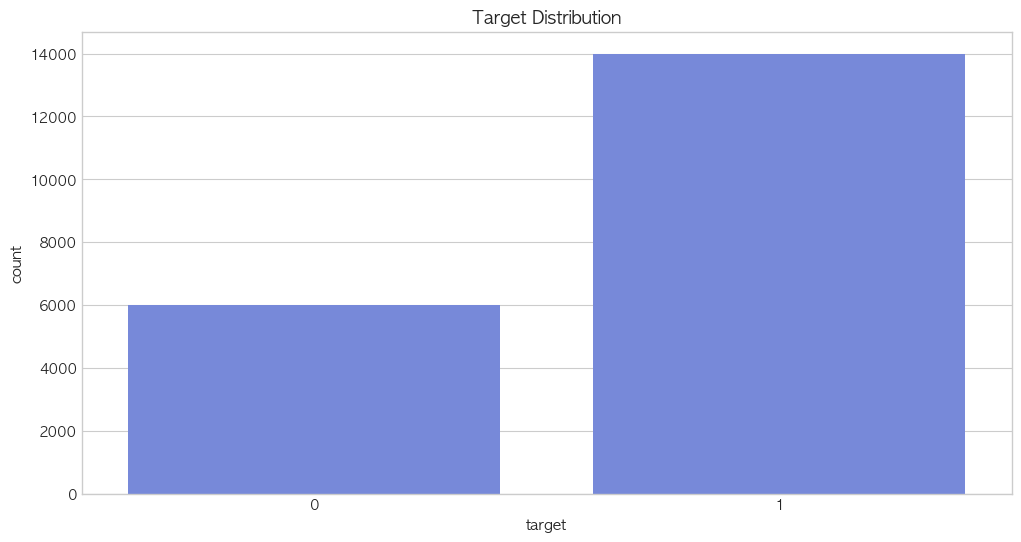

In [13]:
# 타깃 분포 (클래스 불균형 확인)
target_counts = df["target"].value_counts().sort_index()
target_ratio = df["target"].value_counts(normalize=True).sort_index()

print("target count: \n", target_counts)
print("target ratio: \n", target_ratio)

sns.countplot(data=df, x='target')
plt.title("Target Distribution")
plt.show()

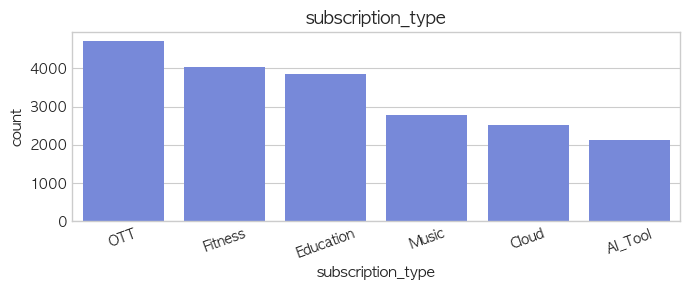

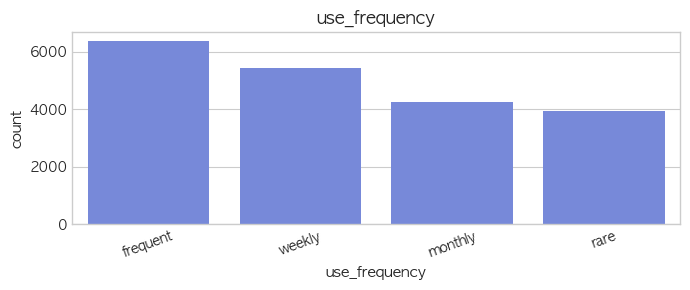

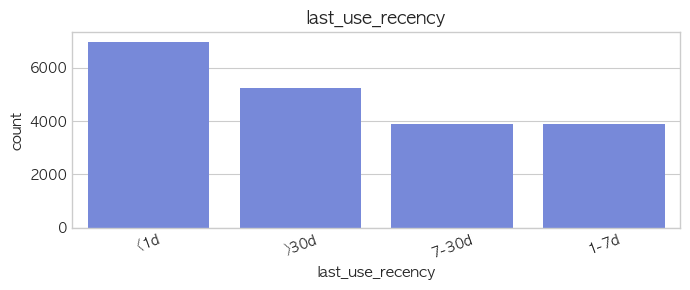

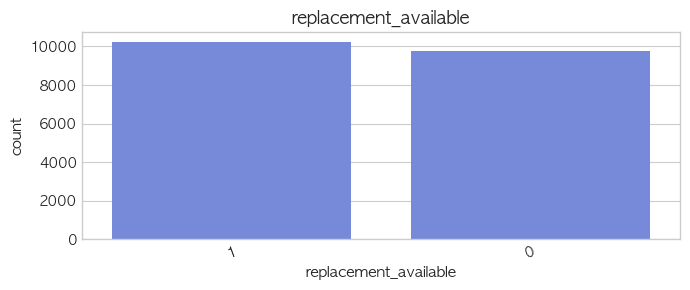

In [17]:
cat_cols = ["subscription_type", "use_frequency", "last_use_recency", "replacement_available"]
ord_cols = ["perceived_necessity", "cost_burden", "would_rebuy"]

for col in cat_cols:
    plt.figure(figsize=(7, 3))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.xticks(rotation=20)
    plt.title(col)
    plt.tight_layout()
    plt.show()

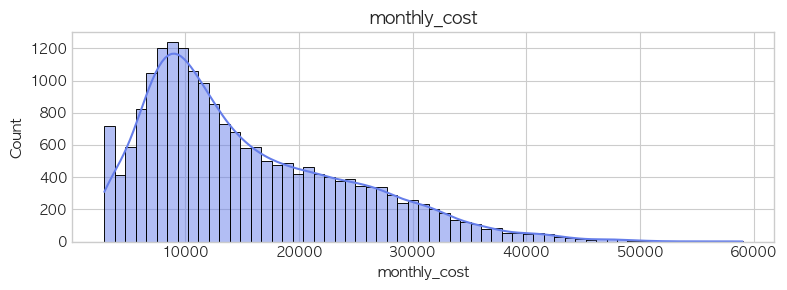

In [18]:
plt.figure(figsize=(8, 3))
sns.histplot(df["monthly_cost"], kde=True)
plt.title("monthly_cost")
plt.tight_layout()
plt.show()

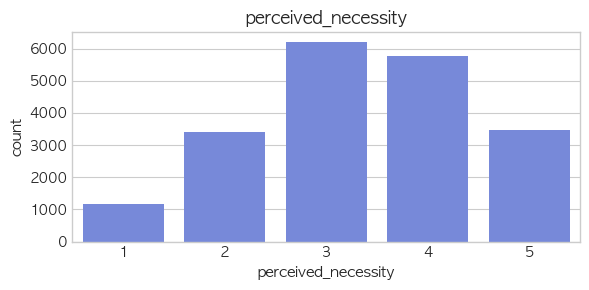

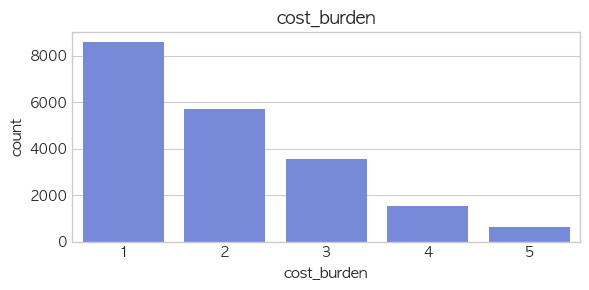

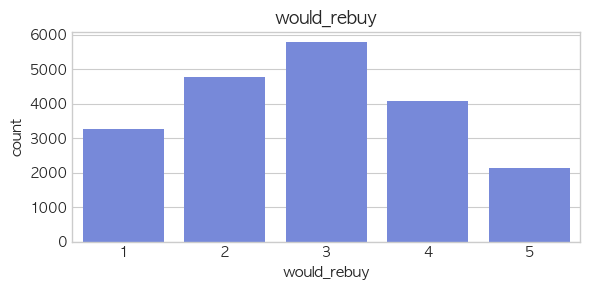

In [21]:
for col in ord_cols:
    plt.figure(figsize=(6, 3))
    sns.countplot(data=df, x=col, order=sorted(df[col].unique()))
    plt.title(col)
    plt.tight_layout()
    plt.show()

In [22]:
# 사용빈도 X 최근샤용일 교차표
p = pd.crosstab(df["use_frequency"], df["last_use_recency"], normalize="index")
display(p)

last_use_recency,1-7d,7-30d,<1d,>30d
use_frequency,,,,
frequent,0.190222,0.078447,0.719069,0.012262
monthly,0.196378,0.314440,0.097131,0.392051
rare,0.057049,0.191430,0.010649,0.740872
weekly,0.295242,0.240860,0.356972,0.106926


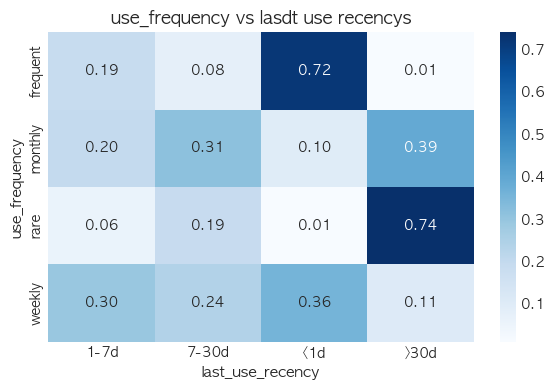

In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(p, annot=True, cmap="Blues", fmt=".2f")
plt.title("use_frequency vs last use recencys")
plt.tight_layout()
plt.show()